<a href="https://colab.research.google.com/github/mailnami-coder/Learn-ML-Basics/blob/main/Univariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Making Up 100 Cups of Coffee (Data Generation)

The Timer (X_large): The computer randomly creates 100 brewing times between 15 and 45 seconds.

The Flavor (y_large) & The Flukes (noise): Generally, any cup brewed longer than 30 seconds is marked as Bitter (1), and shorter is Delicious (0). However, we add noise (flukes) to mimic real life. This means a 28-second cup might accidentally turn out bitter, or a 32-second cup might stay delicious due to an accidental change in grind size.



--- Model Performance Metrics ---
Accuracy on Hidden Test Data: 85.0%

Extended report charts saved as 'coffee_scatter_pipeline.png'


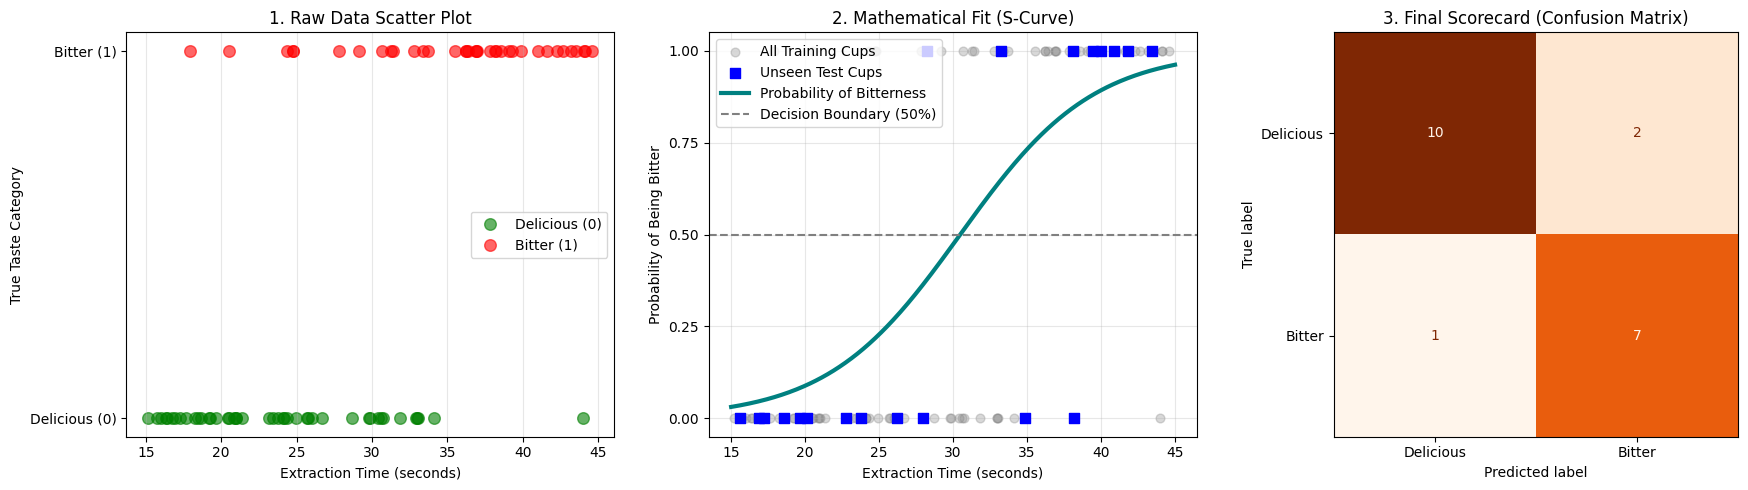

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Generate the dataset (100 cups) with high noise
np.random.seed(42)
X_large = np.random.uniform(15, 45, 100).reshape(-1, 1)

# Noise factor creates real-world flavor overlaps
noise = np.random.normal(0, 8, 100).reshape(-1, 1)
y_large = ((X_large + noise) > 30).astype(int).flatten()

# 2. SPLIT THE DATA (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X_large, y_large, test_size=0.20, random_state=42)

# 3. Train the model ONLY on the Training Set
model = LogisticRegression()
model.fit(X_train, y_train)

# 4. Evaluate the model on the UNSEEN Testing Set
y_test_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_cm = confusion_matrix(y_test, y_test_pred)

print(f"--- Model Performance Metrics ---")
print(f"Accuracy on Hidden Test Data: {test_accuracy * 100:.1f}%\n")

# 5. Plotting: Raw Scatter Plot + Probability S-Curve
# We create a 3-panel figure to showcase the raw scatter data clearly
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# --- PANEL 1: DEDICATED SCATTER PLOT (Raw X vs y) ---
# Separate training points for easy color-coding
ax1.scatter(X_train[y_train == 0], y_train[y_train == 0], color='green', alpha=0.6, s=70, label='Delicious (0)')
ax1.scatter(X_train[y_train == 1], y_train[y_train == 1], color='red', alpha=0.6, s=70, label='Bitter (1)')

ax1.set_title("1. Raw Data Scatter Plot")
ax1.set_xlabel("Extraction Time (seconds)")
ax1.set_ylabel("True Taste Category")
ax1.set_yticks([0, 1])
ax1.set_yticklabels(["Delicious (0)", "Bitter (1)"])
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# --- PANEL 2: PROBABILITY S-CURVE ---
X_curve = np.linspace(15, 45, 300).reshape(-1, 1)
y_prob = model.predict_proba(X_curve)[:, 1]

# Replot scatter on background to see how the curve fits the scatter dots
ax2.scatter(X_train, y_train, color='gray', alpha=0.3, s=40, label='All Training Cups')
ax2.scatter(X_test, y_test, color='blue', marker='s', s=60, zorder=5, label='Unseen Test Cups')
ax2.plot(X_curve, y_prob, color='teal', linewidth=3, label='Probability of Bitterness')
ax2.axhline(0.5, color='gray', linestyle='--', label='Decision Boundary (50%)')

ax2.set_title("2. Mathematical Fit (S-Curve)")
ax2.set_xlabel("Extraction Time (seconds)")
ax2.set_ylabel("Probability of Being Bitter")
ax2.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax2.legend()
ax2.grid(alpha=0.3)

# --- PANEL 3: CONFUSION MATRIX ---
disp = ConfusionMatrixDisplay(confusion_matrix=test_cm, display_labels=["Delicious", "Bitter"])
disp.plot(ax=ax3, cmap='Oranges', colorbar=False)
ax3.set_title("3. Final Scorecard (Confusion Matrix)")

plt.tight_layout()
plt.savefig('coffee_scatter_pipeline.png', dpi=300)
print("Extended report charts saved as 'coffee_scatter_pipeline.png'")
plt.show()
